## 1. Intro

<i>

|    | Task T                                                                                           | Performance measure P                                                           | Experience E                                                                                      |
| -- | ------------------------------------------------------------------------------------------------ | ------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------- |
| 11 | Decide whether to invite a candidate for an interview                                            | Accuracy of prediction (whether the invited candidate is a good fit)            | Candidates’ resumes, past records of successful and unsuccessful hires                            |
| 12 | Predict how much time a peer will need to complete a project                                     | Difference between predicted and actual project duration                        | Historical data of projects with their durations and information about participants               |
| 13 | Predict whether a peer will successfully complete the training program (e.g. School 21)          | Correctness of prediction (success or failure)                                  | Records from the intensive program (bootcamp), project results, and outcomes of previous students |
| 14 | Split crystalline compounds into groups of similar structures                                  | Quality of splitting (e.g. similarity within groups, interpretability)         | Database of crystal structures (e.g. CIF files)                                                   |
| 15 | Identify which programming languages/frameworks are frequently required together in job postings | Accuracy of pattern detection, usefulness of combinations for curriculum design | Large dataset of job postings with listed requirements                                            |


Benefits of using ML in these examples

11. Candidate screening  
ML helps automate resume review when there are thousands of applications. Instead of relying on rigid keyword filters, ML models can capture patterns from past successful hires, reducing manual effort and potentially improving the quality of selected candidates.

12. Project time estimation  
Manual estimation often depends on subjective judgment and can be biased. ML models can learn from many past projects, accounting for multiple factors simultaneously, and provide more reliable estimates, helping peers plan their workload.

13. Predicting study success  
Human evaluation of candidates may be inconsistent or biased. ML enables faster, more objective, and consistent screening, supporting fairer admission decisions and reducing dependency on changing opinions of evaluators.

14. Grouping crystalline compounds  
Traditional classification uses rigid, human-defined criteria that may separate very similar structures. ML-based clustering can reveal hidden similarities and suggest more natural groupings, helping scientists to discover patterns not captured by conventional rules.

15. Job market skill analysis  
Simple correlations might miss complex relationships (e.g., a language is required only in combination with a certain framework). ML can capture such patterns across large job posting datasets, providing more accurate insights for designing training courses or targeted advertising.
</i>

<i>


**Supervised**  

**Classification**: 2 (target=is our prediction correct or not), 4 (target=whether the medicine helps to recover), 5 (target=will the cusomer participate in the promo), 6 (target=is defect or not), 8 (whether user opens link), 10 (target=is anomaly or not: if we already have annotated data), 11 (target=will the candidate be hired), 13 (target=will the peer finish education successfully)  

**Regression**: 1 (target=price), 2 (target=mathematical expectation of the money lost by bank), 3 (target=best time since the last take of the medicine), 7 (target=income), 12 (target=project execution duration)

**Unsupervised**  

**Clustering**: 5 (as a preliminary step in determining which clusters of the clients are interested in the product, making a portrait of a target auditory), 7 (so to just place similar products together), 9 , 14  

**Association**: 7 (so that we can create consumer sets of different but connected products), 15  

**Dimensionality Reduction**: 5, 8, 9, 12 (all used as a preliminary step)
</i>

<i>

**Multiclass classification** is when the target variable can take one of several possible values.  
Example: predicting whether a fruit is an apple, a pear, or an orange.  

**Multilabel classification** is the task of predicting the presence or absence of multiple properties of a sample, where the properties are not mutually exclusive.
Example: determining whether a document touches on the topics of religion, politics, art, or science.
</i>

<i>

The problem of house price estimation described in the theoretical part belongs to **regression**.  

In principle, a regression task can be reduced to classification through stratification of the target. In this case, it is preferable to use ordinal classification so that the valuable information about the order of classes is not lost.
</i>

## 2. Introduction to Data Analysis

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, RobustScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error


In [2]:
data = pd.read_json('data/train.json')

In [3]:
data.shape

(49352, 15)

In [4]:
data.columns

Index(['bathrooms', 'bedrooms', 'building_id', 'created', 'description',
       'display_address', 'features', 'latitude', 'listing_id', 'longitude',
       'manager_id', 'photos', 'price', 'street_address', 'interest_level'],
      dtype='object')

*Target column is 'price'*

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


*There are no missing values, so no empty columns either.*

In [6]:
data.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


In [7]:
data.corr(numeric_only=True)

,bathrooms,bedrooms,latitude,listing_id,longitude,price
bathrooms,1.000000,0.533446,-0.009657,0.000776,0.010393,0.069661
bedrooms,0.533446,1.000000,-0.004745,0.011968,0.006892,0.051788
latitude,-0.009657,-0.004745,1.000000,0.001712,-0.966807,-0.000707
listing_id,0.000776,0.011968,0.001712,1.000000,-0.000907,0.008090
longitude,0.010393,0.006892,-0.966807,-0.000907,1.000000,-0.000087
price,0.069661,0.051788,-0.000707,0.008090,-0.000087,1.000000


In [8]:
df = data[['bathrooms', 'bedrooms', 'interest_level', 'price']]

## 3. Statistical Data Analysis

In [9]:
df.head()

,bathrooms,bedrooms,interest_level,price
4,1.0,1,medium,2400
6,1.0,2,low,3800
9,1.0,2,medium,3495
10,1.5,3,medium,3000
15,1.0,0,low,2795


<Axes: xlabel='price', ylabel='Count'>

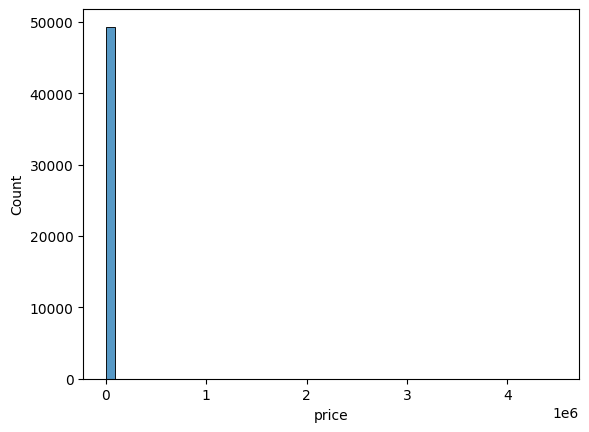

In [10]:
sns.histplot(df.price, bins=50)

*It's not clear, beacause there are big values*

<Axes: xlabel='price'>

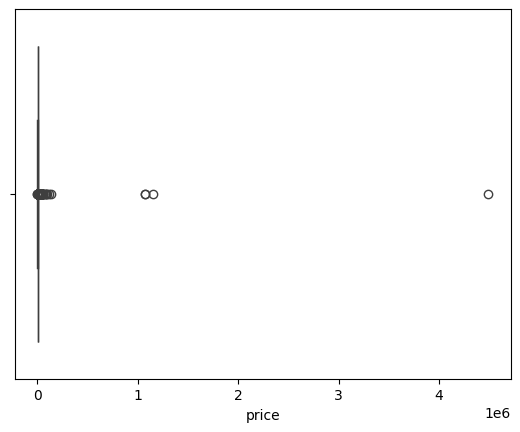

In [11]:
sns.boxplot(x=df.price)

*boxplot shows, that there are very large outliers*

In [12]:
df = df.loc[(df.price.quantile(0.01) < df.price) & (df.price < df.price.quantile(0.99))]

<Axes: xlabel='price', ylabel='Count'>

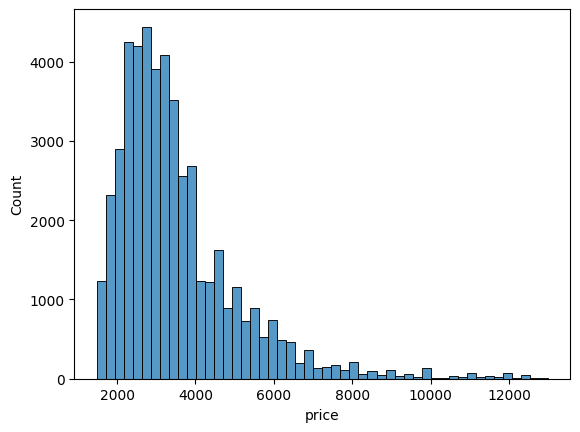

In [13]:
sns.histplot(df.price, bins=50)

*After removing outliers we can see the distribution well because scale changed to normal.*

In [14]:
df.interest_level.dtype.name

'object'

In [15]:
df.interest_level.value_counts()

interest_level
low       33672
medium    11114
high       3557
Name: count, dtype: int64

In [16]:
interest_enc = OrdinalEncoder(categories=[['low', 'medium', 'high']])
df.interest_level = interest_enc.fit_transform(df[['interest_level']])

<Axes: xlabel='bathrooms', ylabel='Count'>

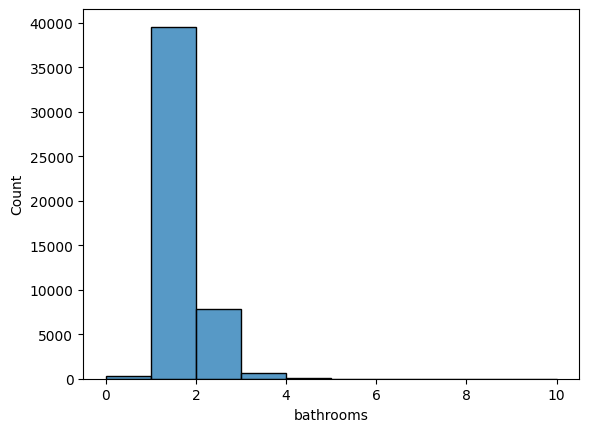

In [17]:
sns.histplot(df.bathrooms, binwidth=1)

<Axes: xlabel='bedrooms', ylabel='Count'>

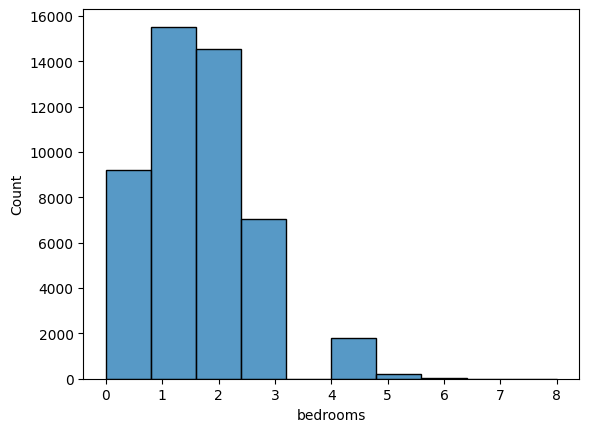

In [18]:
sns.histplot(df.bedrooms, binwidth=0.8)

*It depends on the definition of an outlier. For example standard boxplot algorithm gives that all 'bathrooms' values except 1 are outliers beacuse IQ=0 for 'bathrooms'. But actually all values are meaningful so there're no real outliers in 'bathrooms' and 'bedrooms'*

In [19]:
df.corr()

,bathrooms,bedrooms,interest_level,price
bathrooms,1.000000,0.517200,-0.062819,0.670808
bedrooms,0.517200,1.000000,0.051282,0.547310
interest_level,-0.062819,0.051282,1.000000,-0.199652
price,0.670808,0.547310,-0.199652,1.000000


<Axes: >

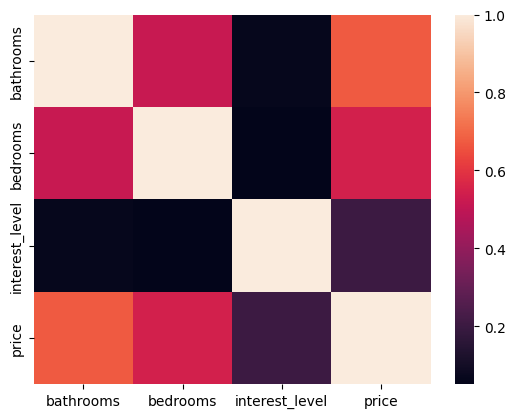

In [20]:
sns.heatmap(df.corr().abs())

*Yes, there's a correlation. Price correlates well with bathrooms and bedrooms*

<Axes: xlabel='price', ylabel='bathrooms'>

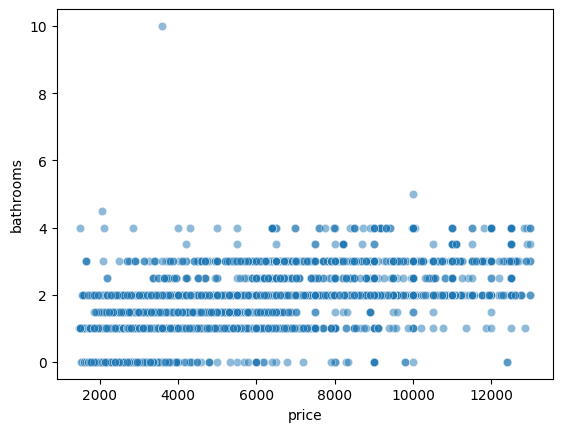

In [21]:
sns.scatterplot(data=df, x='price', y='bathrooms', alpha=0.5)

<Axes: xlabel='price', ylabel='bedrooms'>

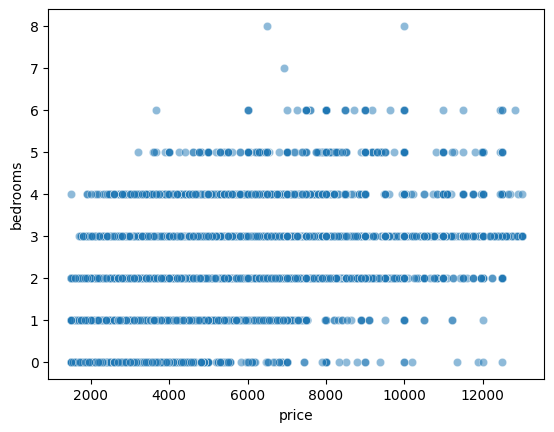

In [22]:
sns.scatterplot(data=df, x='price', y='bedrooms', alpha=0.5)

<Axes: xlabel='price', ylabel='interest_level'>

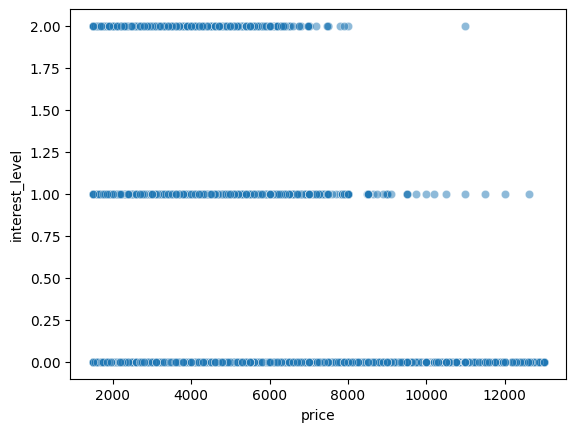

In [23]:
sns.scatterplot(data=df, x='price', y='interest_level', alpha=0.5)

## 4. Creating Features

In [24]:
for col_name in ['bathrooms', 'bedrooms', 'interest_level']:
    df[f'{col_name}_squared'] = df[col_name]**2

In [25]:
df.corr()

,bathrooms,bedrooms,interest_level,price,bathrooms_squared,bedrooms_squared,interest_level_squared
bathrooms,1.000000,0.517200,-0.062819,0.670808,0.955906,0.548426,-0.058710
bedrooms,0.517200,1.000000,0.051282,0.547310,0.478497,0.928282,0.040125
interest_level,-0.062819,0.051282,1.000000,-0.199652,-0.067757,0.047048,0.943959
price,0.670808,0.547310,-0.199652,1.000000,0.646949,0.544612,-0.182283
bathrooms_squared,0.955906,0.478497,-0.067757,0.646949,1.000000,0.521951,-0.061563
bedrooms_squared,0.548426,0.928282,0.047048,0.544612,0.521951,1.000000,0.036408
interest_level_squared,-0.058710,0.040125,0.943959,-0.182283,-0.061563,0.036408,1.000000


*No, squared features are less correlated with the target.*

In [26]:
df_train = pd.read_json('data/train.json')
df_train = df_train[['bathrooms', 'bedrooms', 'price']]

price_lower_bound = df_train.price.quantile(0.01)
price_upper_bound = df_train.price.quantile(0.99)

df_train = df_train[(price_lower_bound < df_train.price) & (df_train.price < price_upper_bound)]


In [27]:
df_test = pd.read_json('data/test.json')
df_test = df_test[['bathrooms', 'bedrooms', 'price']]

df_test = df_test[(price_lower_bound < df_test.price) & (df_test.price < price_upper_bound)]

df_test = df_test[df_test.bathrooms < df_train.bathrooms.max()*1.5]

In [28]:
X_train = df_train.drop(columns='price')
y_train = df_train['price']
X_test = df_test.drop(columns='price')
y_test = df_test['price']

In [29]:
X_scaler = RobustScaler()
X_train = X_scaler.fit_transform(X_train)
X_test = X_scaler.transform(X_test)

In [30]:
poly = PolynomialFeatures(10)

In [31]:
X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

## 5. Linear regression, decision tree and naive model

In [32]:
result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])

In [33]:
def update_tables(result_MAE, result_RMSE, df_train, df_test, model, model_name):
    model.fit(X_train, y_train)
    predict_target_name = f'price_{model_name}'
    df_train[predict_target_name] = model.predict(X_train)
    df_test[predict_target_name] = model.predict(X_test)
    for result_table, metric in zip([result_MAE, result_RMSE], [mean_absolute_error, root_mean_squared_error]):
        train_metric = metric(df_train['price'], df_train[predict_target_name])
        test_metric = metric(df_test['price'], df_test[predict_target_name])
        result_table.loc[len(result_table)] = pd.Series({'model': model_name, 'train': train_metric, 'test': test_metric})


In [34]:
lin_reg = LinearRegression()

In [35]:
update_tables(result_MAE, result_RMSE, df_train, df_test, model=lin_reg, model_name='linreg')

In [36]:
tree_reg = DecisionTreeRegressor(random_state=21)
update_tables(result_MAE, result_RMSE, df_train, df_test, model=tree_reg, model_name='tree')

In [37]:
for df in df_train, df_test:
    for aggfunc in ['mean', 'median']:
        df[f'price_{aggfunc}'] = df.price.agg(aggfunc)

In [38]:
for aggfunc in ['mean', 'median']:
    for result_table, metric in zip([result_MAE, result_RMSE], [mean_absolute_error, root_mean_squared_error]):
        train_metric = metric(df_train.price, df_train[f'price_{aggfunc}'])
        test_metric = metric(df_test.price, df_test[f'price_{aggfunc}'])
        result_table.loc[len(result_table)] = pd.Series({'model': f'naive_{aggfunc}', 'train': train_metric, 'test': test_metric})
        

In [39]:
result_MAE

,model,train,test
0,linreg,753.675997,1134.5627
1,tree,753.675997,756.43029
2,naive_mean,1134.361473,1129.132878
3,naive_median,1082.220859,1079.046996


In [40]:
result_RMSE

,model,train,test
0,linreg,1070.598967,66485.736042
1,tree,1070.598967,1072.226023
2,naive_mean,1585.609099,1573.587796
3,naive_median,1631.719953,1617.946181


*The best model is tree.*